In [2]:
!pip install openpyxl
!pip install seaborn
!pip install imbalanced-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Correlation heatmap
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler # Pre-processing data
from sklearn.preprocessing import OneHotEncoder # One hot encoder
from sklearn.pipeline import make_pipeline # L2 regularization for Logistic Regression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix # Specificity for binary label classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load excel file and convert NaNs in the whole file to 0
df = pd.read_excel('RawData.xlsx').fillna(0)

In [46]:
print(df.shape)
print(df.columns.tolist())

(597, 32)
['Age year', 'Pre-pregnancy BW', 'HT', 'Pre-pregnancy BMI', 'BMI type', 'Total BW', 'Total weight gain', 'Underlying', 'Underlying info', 'Previous macrosomia', 'Prior caesean section', 'P', 'GA week', 'GA day', 'Definite GA', 'GDM', 'PIH', 'Route of delivery', 'Indication', 'Perineal wound', 'Dystocia', 'BW', 'Apgar', 'Neonatal ward', 'PPH', 'PPH info', 'EWG', 'BW comparing  GA', 'Macrosomia', 'Asphyxia', 'Ceasarean section', 'NICU admission']


In [3]:
# Features
categorical_columns = ['BMI type', 'EWG', 'Previous macrosomia', 'Prior caesean section', 'GDM', 'PIH']
X = pd.get_dummies(df[categorical_columns + ['P', 'Definite GA']], columns=categorical_columns, drop_first=True) # Pre-processing categorical data by One Hot Encoder

# Label
y_LGA = df['BW comparing  GA'] # 3 classifications
y_binary = (df['BW comparing  GA'] == 2).astype(int) # binary classification: 0 for non-LGA VS. 1 for LGA
print("Features (X) shape:", X.shape)
print("Label (y) shape:", y_LGA.shape)

Features (X) shape: (597, 10)
Label (y) shape: (597,)


In [ ]:
# Secondary label
y_macrosomia = df['Macrosomia']
y_asphyxia = df['Asphyxia']
y_caesar = df['Ceasarean section']
y_NICU = df['NICU admission']
y_wound = df['Perineal wound']
y_dystocia = df['Dystocia']
y_apgar = df['Apgar']
y_PPH = df['PPH']
y_ward = df['Neonatal ward']
y_route = df['Route of delivery']

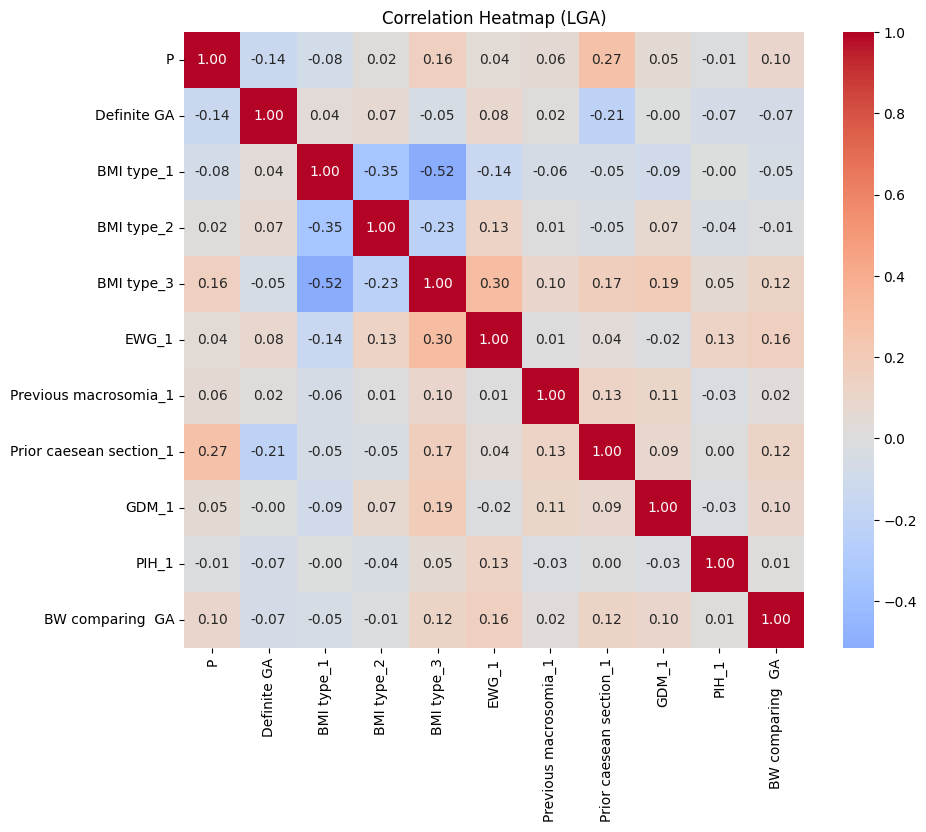

In [5]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(X.join(y_binary).corr(), annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Correlation Heatmap (LGA)")
plt.savefig("figures/heatmap.png", bbox_inches='tight')
plt.show()

In [218]:
# Split data 3 Classifications

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X, y_LGA, test_size=0.2, stratify=y_binary, random_state=42)

In [229]:
# Logistic Regression with L2 Regularization

# 3 Classifications
clf = make_pipeline(StandardScaler(),LogisticRegression(C=1, solver='lbfgs', max_iter=2000,class_weight='balanced')) # Weight imbalanced data (too low amount of LGA samples)
clf.fit(X_train_3, y_train_3)

# Coefficients of features by classification
lr_model = clf.named_steps['logisticregression']
feature_cols = X.columns
coef_df = pd.DataFrame(lr_model.coef_.T,columns=[f"Class {c}" for c in lr_model.classes_],index=feature_cols)
print(coef_df)

# Accuracy
y_train_pred = clf.predict(X_train_3)
y_test_pred = clf.predict(X_test_3)

def calculate_multiclass_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    specificity_per_class = []
    
    for i in range(len(cm)):
        tp = cm[i, i]
        fn = sum(cm[i, :]) - tp
        fp = sum(cm[:, i]) - tp
        tn = sum(sum(cm)) - (tp + fp + fn)
        
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_per_class.append(spec)
    
    return np.mean(specificity_per_class)

train_spec = calculate_multiclass_specificity(y_train_3, y_train_pred)
test_spec = calculate_multiclass_specificity(y_test_3, y_test_pred)

y_probs = clf.predict_proba(X_train_3) #ROC-AUC: distinguish amongst classes
auc = roc_auc_score(y_train_3, y_probs, multi_class='ovr', average='macro')
print(f"\nTraining Data\nROC-AUC: {auc:.4f}")

print(classification_report(y_train_3, y_train_pred))

print(f"Specificity: {train_spec:.4f}\n")


y_probs = clf.predict_proba(X_test_3) #ROC-AUC
auc = roc_auc_score(y_test_3, y_probs, multi_class='ovr', average='macro')
print(f"Test Data\nROC-AUC: {auc:.4f}")
print(classification_report(y_test_3, y_test_pred))


print(f"Specificity: {test_spec:.4f}")

                          Class 0   Class 1   Class 2
P                        0.061481 -0.199921  0.138440
Definite GA              0.117955  0.006882 -0.124837
BMI type_1               0.065905 -0.049571 -0.016334
BMI type_2               0.029938 -0.051271  0.021332
BMI type_3               0.016316 -0.173098  0.156782
EWG_1                   -0.017015 -0.299682  0.316697
Previous macrosomia_1    0.303824 -0.092210 -0.211614
Prior caesean section_1  0.003140 -0.329869  0.326729
GDM_1                   -0.163300  0.052547  0.110752
PIH_1                   -0.091524  0.200004 -0.108480

Training Data
ROC-AUC: 0.6702
              precision    recall  f1-score   support

           0       0.86      0.33      0.48       396
           1       0.11      0.60      0.19        35
           2       0.18      0.52      0.26        46

    accuracy                           0.37       477
   macro avg       0.38      0.49      0.31       477
weighted avg       0.74      0.37      0.44      

In [9]:
# Split data binary

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X, y_binary, test_size=0.2, stratify=y_binary, random_state=42)

In [10]:
# Logistic Regression with L2 Regularization

clf = make_pipeline(StandardScaler(),LogisticRegression(C=1, solver='lbfgs', max_iter=2000,class_weight='balanced'))
clf.fit(X_train_2, y_train_2)

# Fixed for Binary Logistic Regression
lr_model = clf.named_steps['logisticregression']
feature_cols = X.columns

# Binary models have only 1 column of coefficients
coef_df = pd.DataFrame(lr_model.coef_.T, columns=['Coefficient'], index=feature_cols)
print(coef_df)

# Accuracy
y_train_pred = clf.predict(X_train_2)
y_test_pred = clf.predict(X_test_2)

# For Training Data
y_probs_train = clf.predict_proba(X_train_2)[:, 1]  # Added [:, 1]
auc_train = roc_auc_score(y_train_2, y_probs_train) # Removed multi_class/average
print(f"\nTraining Data\nROC-AUC: {auc_train:.4f}")

print(classification_report(y_train_2, y_train_pred))

tn, fp, fn, tp = confusion_matrix(y_train_2, y_train_pred).ravel()

train_specificity = tn / (tn + fp)

print(f"Specificity: {train_specificity:.4f}\n")

# For Test Data
y_probs_test = clf.predict_proba(X_test_2)[:, 1]   # Added [:, 1]
auc_test = roc_auc_score(y_test_2, y_probs_test)   # Removed multi_class/average
print(f"Test Data\nROC-AUC: {auc_test:.4f}")
print(classification_report(y_test_2, y_test_pred))

tn, fp, fn, tp = confusion_matrix(y_test_2, y_test_pred).ravel()

test_specificity = tn / (tn + fp)

print(f"Specificity: {test_specificity:.4f}")

                         Coefficient
P                           0.074498
Definite GA                -0.184040
BMI type_1                 -0.040235
BMI type_2                  0.008753
BMI type_3                  0.199021
EWG_1                       0.326463
Previous macrosomia_1      -0.456451
Prior caesean section_1     0.325910
GDM_1                       0.210989
PIH_1                      -0.059654

Training Data
ROC-AUC: 0.7021
              precision    recall  f1-score   support

           0       0.93      0.68      0.79       431
           1       0.15      0.54      0.24        46

    accuracy                           0.67       477
   macro avg       0.54      0.61      0.51       477
weighted avg       0.86      0.67      0.74       477

Specificity: 0.6821

Test Data
ROC-AUC: 0.6516
              precision    recall  f1-score   support

           0       0.92      0.70      0.80       108
           1       0.14      0.42      0.20        12

    accuracy            

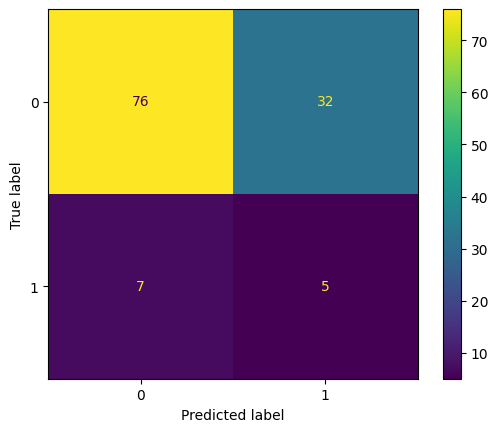

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test_2, y_test_2)

plt.savefig("figures/confusion_matrix.png", bbox_inches='tight')
plt.show()

In [231]:
# Since coefficient of previous macrosomia_1 is -0.456451, which is against medical knowledge,
# we display the data of sample with history of previous macrosomia
pd.crosstab(df['Previous macrosomia'],y_binary,margins=True)

BW comparing GA,0,1,All
Previous macrosomia,,,
0,534,57,591
1,5,1,6
All,539,58,597


In [232]:
# Explanation: sample size is too small and the events are rare especially in Asians where people has lower weight than White people in general
# (lower incidence of fetal macrosomia)

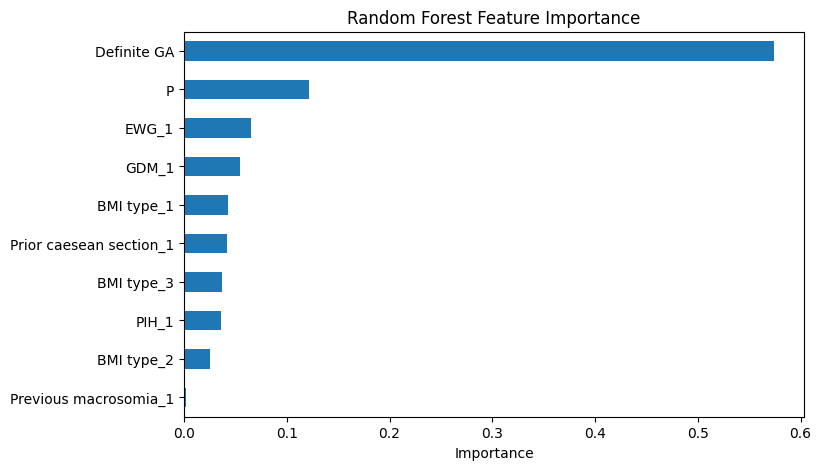

In [8]:
# RandomForestClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y_LGA, test_size=0.2, stratify=y_binary, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh',figsize=(8,5))
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.savefig("figures/feature_importance_plot.png", bbox_inches='tight')
plt.show()

In [207]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    clf,
    X,
    y_LGA,
    cv=cv,
    scoring='f1_macro'
)

print("Macro F1 Scores:", scores)
print("Mean Macro F1:", scores.mean())

Macro F1 Scores: [0.26569095 0.26700362 0.2828596  0.22379928 0.21921042]
Mean Macro F1: 0.25171277529516356
